# Resonance of a series RLC resonant circuit

## Some important background

Dealing with oscillatory phenomena numerically sometimes leads to unexpected surprises. Problems can occur when you are trying to plot an oscillating function with an insufficient number of points, where there are only a few points per period (or less). This is a sampling problem, which can take various forms in physics, signal analysis, etc... Properly sampling a function is an important question in many practical experimental situations. Learn more https://en.wikipedia.org/wiki/Sampling_(signal_processing)

To make this clear with a practical example, imagine you want to plot the decaying oscillatory function

$$\cos(30x)e^{-x/4}$$

The period for this function is $2\pi/30 \approx 0.209$. 

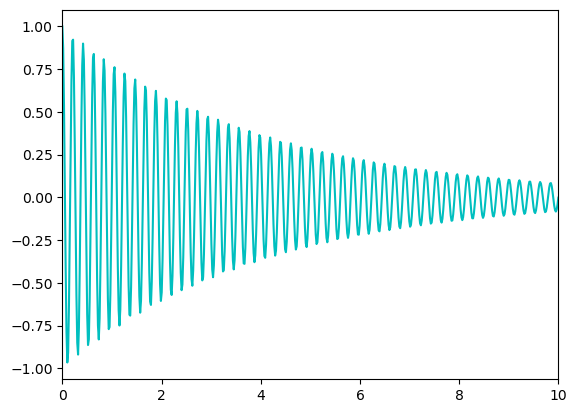

In [5]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(0, 10, 600)
#plt.figure(figsize=(8, 5))
plt.plot(x, np.cos(30. * x) * np.exp(-x / 4.), 'c-')
plt.xlim([0, 10])
plt.show()

Now imagine we plot the same function with the following sampling, which is approximately half of the oscillation period. What happens is that you find that there is an artificial 'beat' pattern, shown in purple.

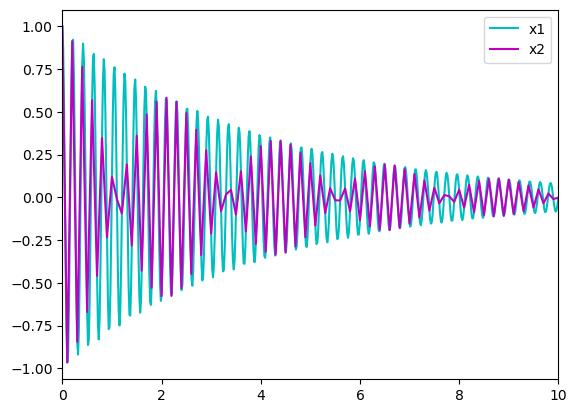

In [6]:
# Sampling frequency Range is ~ 1/6 of x2
# (3x as wide and ~1/2 as many points)
x2 = np.linspace(0, 30, 301)
#plt.figure(figsize=(8, 5))
plt.plot(x, np.cos(30. * x) * np.exp(-x / 4.), 'c-', label="x1")
plt.plot(x2, np.cos(30. * x2) * np.exp(-x2 / 4.), 'm-', label="x2")
plt.xlim([0, 10])
plt.legend()
plt.show()

It is important to be aware of this potential problem when plotting highly oscillating functions. This problem is also known as "aliasing", and it occurs when you under-sample a high frequency wave, causing you to misinterpret it as a longer wavelength. 

The concept of Nyquist frequency is particularly important

# RLC resonant circuit

So that our solutions are as general as possible, we are going to generate random values for inductance and capacitance in the circuit, with some constraints. Your solutions from one execution of your code to the next might be multiple orders of magnitude different, so decisions about which ranges of values to include should be automated to some extent so that the graphs are able to always show the desired features clearly.

Choose random values of $L$ and $C$, with the following constraints:

1. Start by generating a two-digit integer, $a_L$ between 10 and 99 (inclusive), and
1. A random integer, $b_L$, between -5 and -9 (inclusive) for the exponent.

The inductance is then given by $L = {a_L} \times 10^{b_L}$ Henries.

Repeat this process using the same constraints, but with _**new**_ random numbers to get the capacitance, $C = {a_C} \times 10^{b_C}$ Farad.

Finally, we determine three values of $R$, to represent the underdamped, critically damped and overdamped cases, respectively, based on the already determined values of $L$ and $C$:

$$R_1 = \frac{1}{10} \times 2\pi\sqrt{\frac{L}{C}}$$
$$R_2 = 2\pi\sqrt{\frac{L}{C}}$$
$$R_3 = 5 \times 2\pi\sqrt{\frac{L}{C}}$$

In [4]:
import numpy as np

a_L = np.random.randint(10,
                        100)  # generates a two-digit integer between 10 and 99
b_L = np.random.randint(-9, -4)  # generates an integer between -9 and -5
L = a_L * 10**b_L  # Inductance in Henries (H)

a_C = np.random.randint(10,
                        100)  # generates a two-digit integer between 10 and 99
b_C = np.random.randint(-9, -4)  # generates an integer between -9 and -5
C = a_C * 10**b_C  # Capacitance in Farads (F)

# Resisntance in Ohms (Ω) for underdamped case R < 2√L/C
R1 = (1 / 10) * 2 * np.sqrt(L / C)
# Resisntance in Ohms (Ω) for critically damped case R = 2√L/C
R2 = 2 * np.sqrt(L / C)
# Resisntance in Ohms (Ω) for overdamped case R > 2√L/C
R3 = 5 * 2 * np.sqrt(L / C)

#### Part 2: Time evolution of the current in the three circuits

We will use a primary observable of the current in the circuit $I(t)=dq(t)/dt$ to describe what is happening in each circuit. The current in the circuit is driven by an AC voltage source, with amplitude $V_0$ and frequency $\omega$, much like how you can increase the amplitude of a person on a swing by providing an external periodic push. We will have our voltage source provide its voltage at a frequency of $\omega = \omega_0 = 1/\sqrt{LC}$ to match the resonant frequency of the circuit, much like how you want to match the timing of your pushes to the oscillation frequency of the person on the swing.

These types of systems can take a while to settle into their steady-state oscillatory behaviour, so we want to see how long it takes each circuit to get to get to a steady-state amplitude for the current, starting from an initial state of no charge on the capacitor, $q(0)=0$ and no current in the circuit, $I(0)=0$.

**The task:** 

* Generate a 3-panel figure that shows the time evolution of $I(t)$ for the three cases above, driven by a sinusoidal voltage of $(V_0 = 0.1\textrm{V})$ at a frequency of $\omega = \omega_0$. Start with the initial conditions of no charge stored in the capacitor and no current in the circuit, $q(0) = I(0) = 0$.
* Ensure that your code chooses the time interval and time steps wisely so that it captures the behaviour of the oscillator, such that you can see the evolution (known as the transient) from  $I(0) = 0$ to the stable amplitude of the oscillating current. One challenge is to write the program so that it will work well over the large range of possible $L$ and $C$ values generated from the random numbers, will work well across the three types of damping, and will still generate plots showing the requested features. You should test your code with the Validate button several times, which should generate new random values of $L$ and $C$ to ensure that your plots look good each time.

**The small details:**

* The figure should consist of _three_ vertically stacked subplots, each showing the behaviour for one of the damping cases, clearly labelled as underdamped, critically damped and overdamped.
* The values of the randomly generated R, L and C should be indicated in the titles of each panel.
* You should use a common time interval across all three subplots.

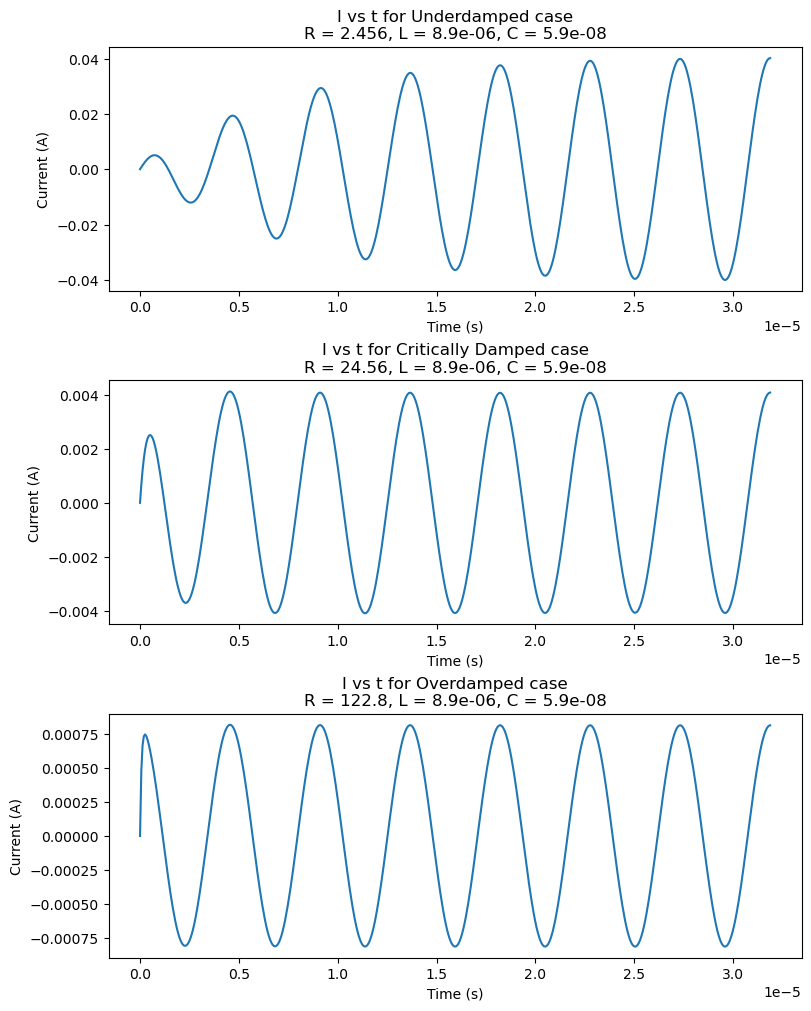

In [16]:
# Generate I vs t figures here.
# YOUR CODE HERE
from scipy import integrate
import matplotlib.pyplot as plt

q0 = 0  # initial charge in coulombs (C)
I0 = 0  # initial current in amps (A)
V0 = 0.1  # amplitude of sinusoidal voltage in volts (V)
ω = 1 / np.sqrt(
    L * C
)  # natural angular frequency of the capacitor/inductor combination (rad/s)


def dydt(
    t, y_arr, R
):  # function that returns numpy arrays of all the  values of dq/dt and dI/dt at a given time
    q = y_arr[0]  # charge q
    qt = y_arr[1]  # I = dq/dt (current)
    return np.array([
        qt, (1 / L * V0 * np.cos(ω * t)) - (R / L * qt) - (1 / (L * C) * q)
    ])  # this is [I, dI/dt]


# 1d time array
t_arr = np.linspace(0, 7 * ((2 * np.pi) / ω),
                    500)  # max time is 7 periods of the oscillating signal

# initial conditions for q and I
y0_arr = np.array([q0, I0])

# Solving the differential equation for Underdamped case, R = R1
sol_1 = integrate.solve_ivp(dydt, (t_arr[0], t_arr[-1]),
                            y0_arr,
                            t_eval=t_arr,
                            args=(R1, ),
                            method='LSODA')

#solve_ivp returns a bunch, we must extract the arrays containing the solution q and I values and the time points at which they were calculated, for the underdamped case;
tsol1 = sol_1['t']  # time points
qsol1 = sol_1['y'][0]  # array of q values (first column) for underdamped case
Isol1 = sol_1['y'][1]  # array of I values (second column) for underdamped case

# Solving the differential equation for Critically Damped case, R = R2
sol_2 = integrate.solve_ivp(dydt, (t_arr[0], t_arr[-1]),
                            y0_arr,
                            t_eval=t_arr,
                            args=(R2, ),
                            method='LSODA')

#We must extract the arrays containing the solution q and I values  and the time points at which they were calculated from the bunch returned by solve_ivp, for the critically damped case;
tsol2 = sol_2['t']  # time points
qsol2 = sol_2['y'][
    0]  # array of q values (first column) for critically damped case
Isol2 = sol_2['y'][
    1]  # array of I values (second column) for critically damped case

# Solving the differential equation for Overdamped case, R = R3
sol_3 = integrate.solve_ivp(dydt, (t_arr[0], t_arr[-1]),
                            y0_arr,
                            t_eval=t_arr,
                            args=(R3, ),
                            method='LSODA')

#We must extract the arrays containing the solution q and I values  and the time points at which they were calculated from the bunch returned by solve_ivp, for the overdamped case;
tsol3 = sol_3['t']  # time points
qsol3 = sol_3['y'][0]  # array of q values (first column) for overdamped case
Isol3 = sol_3['y'][1]  # array of I values (second column) for overdamped case

fig, axes = plt.subplots(3, 1, figsize=(8, 10), constrained_layout=True)

cases = [
    (axes[0], Isol1, "Underdamped", R1),
    (axes[1], Isol2, "Critically Damped", R2),
    (axes[2], Isol3, "Overdamped", R3),
]

for ax, I, label, R in cases:
    ax.plot(t_arr, I)
    ax.set_xlabel("Time (s)")  # keep x-label on every subplot
    ax.set_ylabel("Current (A)")
    ax.set_title(
        f"I vs t for {label} case\n"
        f"R = {R:.4g}, L = {L:.4g}, C = {C:.4g}"
    )

plt.show()

#### Part 3: Resonance plots

Lastly, we want to explore how the steady-state amplitude in each of the three circuits depends on the frequency $(\omega)$ of the sinusoidal driving voltage. Resonance, which occurs when the provided driving frequency closely matches the natural/resonant frequency of the system, is famously the cause of the Tacoma Narrows bridge collapse.

To explore the dependence of the steady-state amplitude of the current on the frequency $(\omega)$ of the sinusoidal driving voltage, generate another figure with three vertically-stacked subplots. Each panel/subplot should show a plot of the steady-state amplitude of the current vs the frequency of the driving voltage for a range from 

$$0.1 \frac{\omega_0}{2 \pi} \; \textrm{ to }\; 2 \frac{\omega_0}{2 \pi}.$$.

The three panels should show the resonance curves (amplitude of the steady-state current vs $\omega$), clearly labelled for the three damping cases. For each point you plot, the current should represent the amplitude of the response current (for a drive amplitude of $V_0 = 0.1\textrm{V}$) at a time _after_ the transient behaviour has died away, such that and the current has stabilized to a steady sinusoidal oscillation. Your calculations should be made at frequencies spaced closely enough that when plotted with a continuous line, the curves are smooth. The values of R, L and C should be indicated in the titles of each panel. The plots should use Hz units ($\omega/2\pi$).

This will require calling `solve_ivp()` numerous times and will require more cpu time to execute than anything we have seen so far, though should in total not take more than a minute or so.

**The small details:**

* The figure should consist of _three_ vertically stacked subplots, each showing the behaviour for one of the damping cases, clearly labelled as underdamped, critically damped and overdamped.
* The values of R, L and C should be indicated in the titles of each panel.

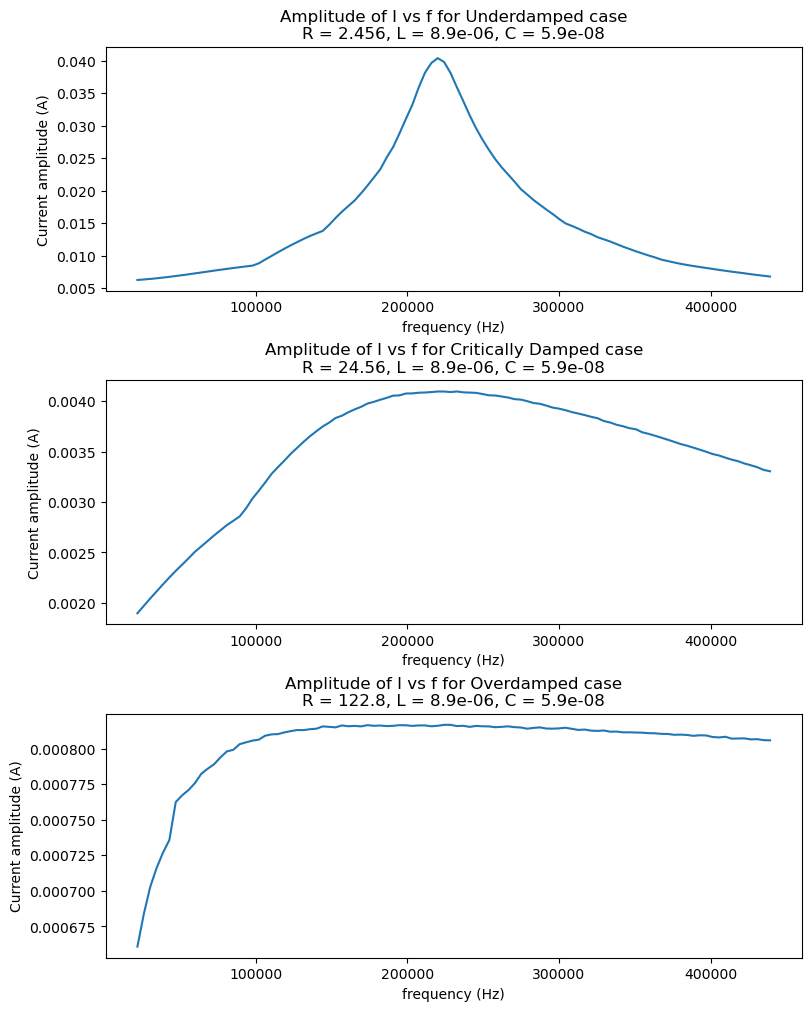

In [15]:
def dydt2(t, y_arr, R, ω1):  # new function defined with ω1 as added parameter
    q = y_arr[0]  # charge q
    qt = y_arr[1]  # I = dq/dt (current)
    return np.array([
        qt, (1 / L * V0 * np.cos(ω1 * t)) - (R / L * qt) - (1 / (L * C) * q)
    ])  # this is [I, dI/dt]


ang_f = np.array([])  # empty array to be filled with angular frequency values
amp1 = np.array(
    []
)  # empty array to be filled with current amplitude values for underdamped case
amp2 = np.array(
    []
)  # empty array to be filled with current amplitude values for critically damped case
amp3 = np.array(
    []
)  # empty array to be filled with current amplitude values for overdamped case
wlist = np.linspace(
    0.1 * ω, 2 * ω, 100
)  # range of values from 0.1-2 times the natural angular frequency of the capacitor/inductor combination

for i in wlist:  # loop so we can run solve_ivp for each of the angular frequency values in wlist, for each of the three cases
    # Solving the differential equation for Underdamped case, R = R1
    sol1 = integrate.solve_ivp(dydt2, (t_arr[0], t_arr[-1]),
                               y0_arr,
                               t_eval=t_arr,
                               args=(R1, i),
                               method='LSODA')

    a = (
        np.max(sol1['y'][1]) - np.min(sol1['y'][1])
    ) / 2  # this is the amplitude of the current values for the underdamped case
    amp1 = np.append(amp1,
                     a)  # appends the array amp1 with each amplitude value
    ang_f = np.append(
        ang_f, i)  # appends the array ang_f with each angular frequency value

    # Solving the differential equation for Critically Damped case, R = R2
    sol2 = integrate.solve_ivp(dydt2, (t_arr[0], t_arr[-1]),
                               y0_arr,
                               t_eval=t_arr,
                               args=(R2, i),
                               method='LSODA')

    b = (
        np.max(sol2['y'][1]) - np.min(sol2['y'][1])
    ) / 2  # this is the amplitude of the current values for the critically damped case
    amp2 = np.append(amp2,
                     b)  # appends the array amp2 with each amplitude value

    # Solving the differential equation for underdamped case, R = R3
    sol3 = integrate.solve_ivp(dydt2, (t_arr[0], t_arr[-1]),
                               y0_arr,
                               t_eval=t_arr,
                               args=(R3, i),
                               method='LSODA')

    c = (
        np.max(sol3['y'][1]) - np.min(sol3['y'][1])
    ) / 2  # this is the amplitude of the current values for the overdamped case
    amp3 = np.append(amp3,
                     c)  # appends the array amp3 with each amplitude value

f = ang_f / (2 * np.pi)  # changing angular frequency (rad/s) to frequency (Hz)

fig, axes = plt.subplots(3, 1, figsize=(8, 10), constrained_layout=True)

cases = [
    (axes[0], amp1, "Underdamped", R1),
    (axes[1], amp2, "Critically Damped", R2),
    (axes[2], amp3, "Overdamped", R3),
]

for ax, amp, label, R in cases:
    ax.plot(f, amp)
    ax.set_xlabel("frequency (Hz)")
    ax.set_ylabel("Current amplitude (A)")
    ax.set_title(
        f"Amplitude of I vs f for {label} case\n"
        f"R = {R:.4g}, L = {L:.4g}, C = {C:.4g}"
    )

plt.show()